624000


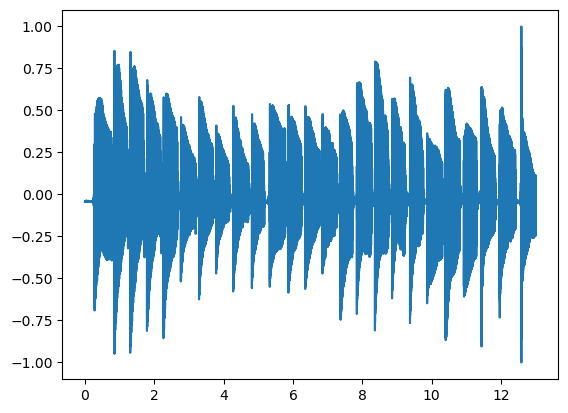

In [29]:
import wave
import numpy
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import filtfilt
from scipy import io
# open the audio file and extract some information
# spf = wave.open('/home/gerald/workspace/src/GuitarMidi-LV2/assets/single-note/Guitar MIDI test.wav','r')
# (nChannels, sampWidth, sampleRate, nFrames, compType, compName) = spf.getparams()

sampleRate,input_signal=io.wavfile.read('/home/gerald/workspace/src/GuitarMidi-LV2/assets/trainingdata/chromatic run/session_Audio 1.wav')
midi_file='/home/gerald/workspace/src/GuitarMidi-LV2/assets/trainingdata/chromatic run/session_NNTranscription-1-t1.mid'

audio=input_signal#[:,1];

audiomin=numpy.min(audio)
audiomax=numpy.max(audio)

audio=numpy.multiply((audio-audiomin)/(audiomax-audiomin),2)-1
print(len(audio))
nFrames =input_signal.shape[0]
time=numpy.linspace(0,len(audio)/sampleRate,len(audio))

plt.plot(time, audio, label='Input')



# # extract audio from wav file
# input_signal = spf.readframes(-1)


# input_signal = numpy.fromstring(input_signal)
# spf.close()



# # ceate output file
# wav_out = wave.open("output.wav", "w")
# wav_out.setparams((nChannels, sampWidth, sampleRate, nFrames, compType, compName))

# # write to output file
# wav_out.writeframes(output_signal.tobytes())
# wav_out.close()

# # plot the signals
# t = numpy.linspace(0, nFrames/sampWidth, nFrames, endpoint = False)
# plt.plot(t, input_signal, label='Input')
# plt.plot(t, output_signal, label='Output')
# plt.show()


num filters:312
Downsampling data by a factor of 1000...
(312, 624000)
Downsampled array shape: (312, 624)
Creating heatmap...


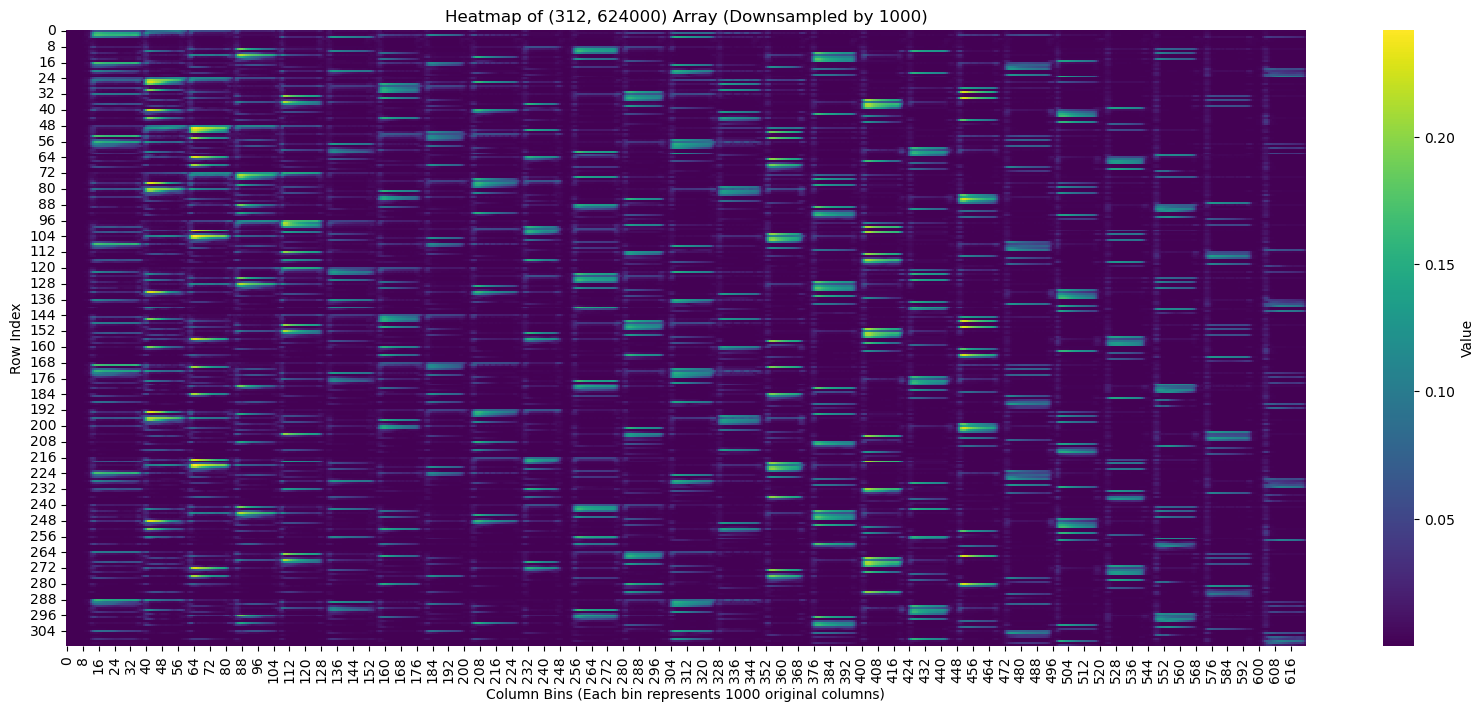

Heatmap displayed.


In [38]:
import numpy as np
import seaborn as sns
num_harmonics=4 
num_frets=13
num_strings=6
class Filter:
    def __init__(self, fret,stringid,harmonic,center_freq, bw,sample_rate):
        self.id=fret*num_strings*num_harmonics+stringid*num_harmonics+harmonic
        self.sample_rate=sample_rate
            
        # create the filter
        N = 2
        low = (center_freq-bw/2) 
        high = (center_freq+bw/2) 
        #self.b, self.a = signal.ellip(N,0.5,40,[low, high], btype='band',fs=sampleRate)
        self.b, self.a =signal.butter(N, [low, high], btype='band',fs=sampleRate)
        
    def process(self,input_audio,filterbank_out: np.array):
        filterbank_out[self.id]=np.abs(signal.filtfilt(self.b, self.a, input_audio))


class HarmonicGroup:
    def __init__(self,fret,stringid ,center_freq, bw,sample_rate):
        self.harmonics=[]
        
        for h in range(1,num_harmonics+1):
            self.harmonics.append(Filter(fret,stringid,h-1,center_freq*h,bw,sample_rate))
    
            
    def process(self, input_audio, filterbank_out: np.array):
        res=filterbank_out
        for h in self.harmonics:
            #filterbank_out.append(h.process(input_audio))
            h.process(input_audio,filterbank_out)
            
        return res
    def get_num_filters(self):
        return len(self.harmonics)
          
            
class Fret:
    def __init__(self,fret,s0,s1,s2,s3,s4,s5, bw,sample_rate):
        
        self.strings=[]
        self.strings.append(HarmonicGroup(fret,0,s0,bw,sample_rate))
   
        self.strings.append(HarmonicGroup(fret,1,s1,bw,sample_rate))

        self.strings.append(HarmonicGroup(fret,2,s2,bw,sample_rate))

        self.strings.append(HarmonicGroup(fret,3,s3,bw,sample_rate))

        self.strings.append(HarmonicGroup(fret,4,s4,bw,sample_rate))

        self.strings.append(HarmonicGroup(fret,5,s5,bw,sample_rate))

        
    def process(self, input_audio, filterbank_out: np.array):
    
        for h in self.strings:
            #filterbank_out.append(h.process(input_audio,filterbank_out))
            h.process(input_audio,filterbank_out)
      
    def get_num_filters(self):
        res=0
        for h in self.strings:
            res=res+h.get_num_filters()
            
        return res
            
class FretBoard:
    def __init__(self,bw,sample_rate):
        self.frets=[]
       
        self.frets.append(Fret(0,82,11,147,196,247,329,bw,sample_rate))
        self.frets.append(Fret(1,87,117,156,208,262,349,bw,sample_rate))
        self.frets.append(Fret(2,92,123,165,220,277,370,bw,sample_rate))
        self.frets.append(Fret(3,98,131,175,233,294,392,bw,sample_rate))
        self.frets.append(Fret(4,104,139,185,247,311,415,bw,sample_rate))
        self.frets.append(Fret(5,110,147,196,262,329,440,bw,sample_rate))
        self.frets.append(Fret(6,117,156,208,277,349,466,bw,sample_rate))
        self.frets.append(Fret(7,123,165,220,294,370,494,bw,sample_rate))
        self.frets.append(Fret(8,131,175,233,311,392,523,bw,sample_rate))
        self.frets.append(Fret(9,139,185,247,329,415,554,bw,sample_rate))
        self.frets.append(Fret(10,147,196,262,349,440,587,bw,sample_rate))
        self.frets.append(Fret(11,156,208,277,370,466,622,bw,sample_rate))
        self.frets.append(Fret(12,165,220,294,392,494,659,bw,sample_rate))
        
    def process(self, input_audio, filterbank_out: np.array):
      
        for h in self.frets:
            # filterbank_out.append(h.process(input_audio,filterbank_out))    
            res=h.process(input_audio,filterbank_out)
       
    def get_num_filters(self):
        res=0
        for h in self.frets:
            res=res+h.get_num_filters()
            
        return res

filter =FretBoard(20,sampleRate)
numfilters=filter.get_num_filters()
print('num filters:'+str(numfilters))
audiolength=len(audio)

lencut=50*sampleRate

# lencut=len(audio)
audiocut=audio[:lencut]
# audiocut=np.abs(audiocut)

filterbank_out=np.zeros((numfilters,len(audiocut)))
# print(filterbank_out.shape)
# filterbank_out=np.expand_dims(filterbank_out, axis=0)
filter.process(audiocut,filterbank_out)
# print(filterbank_out.shape)
# print(len(filterbank_out))
# It's best practice to convert your list of lists to a NumPy array.
# Matplotlib can handle lists of lists directly, but NumPy arrays are
# more efficient and offer more features for data manipulation.
# heatmap_data = filterbank_out#np.array(filterbank_out)
def plot_heatmap(plotdata):
    num_cols=plotdata.shape[1]
    num_rows=plotdata.shape[0]
    downsample_factor = 1000
    # --- Downsampling the data ---
    print(f"Downsampling data by a factor of {downsample_factor}...")
    # Calculate the new number of columns after downsampling
    new_num_cols = num_cols // downsample_factor

    # Ensure the original number of columns is a multiple of the downsample_factor
    # If not, you might lose some data at the end or need a more complex aggregation.
    # For simplicity, we'll slice to a multiple of downsample_factor
    effective_cols = new_num_cols * downsample_factor
    data_sliced = plotdata[:, :effective_cols]
    print(data_sliced.shape)
    # Reshape the data for averaging:
    # -1: infer dimension
    # downsample_factor: group columns into blocks
    # num_rows: keep rows as isp
    # This reshapes (19, M*N) to (19, M, N)
    reshaped_data = data_sliced.reshape(num_rows, new_num_cols, downsample_factor)

    # Average along the last axis (the downsample_factor axis)
    downsampled_data = np.max(reshaped_data, axis=2)

    print(f"Downsampled array shape: {downsampled_data.shape}")

    # --- Plotting the Heatmap ---
    print("Creating heatmap...")
    plt.figure(figsize=(20, 8)) # Adjust figure size as needed, especially width for more columns
    sns.heatmap(downsampled_data, cmap='viridis', cbar_kws={'label': 'Value'})
    plt.title(f'Heatmap of ({num_rows}, {num_cols}) Array (Downsampled by {downsample_factor})')
    plt.xlabel(f'Column Bins (Each bin represents {downsample_factor} original columns)')
    plt.ylabel('Row Index')
    plt.show()
    print("Heatmap displayed.")
plot_heatmap(filterbank_out)


Filter Coefficients (b - numerator): [ 2.92597074e-12  0.00000000e+00 -1.17038830e-11  0.00000000e+00
  1.75558245e-11  0.00000000e+00 -1.17038830e-11  0.00000000e+00
  2.92597074e-12]
Filter Coefficients (a - denominator): [  1.          -7.9923371   27.94720933 -55.84417204  69.74451912
 -55.74874407  27.8517771   -7.95143454   0.9931822 ]
Designed a 4th order Elliptic (Cauer) bandpass filter with cutoff frequencies 100 Hz and 120 Hz.
Passband Ripple (rp): 0.5 dB, Stopband Attenuation (rs): 40 dB.


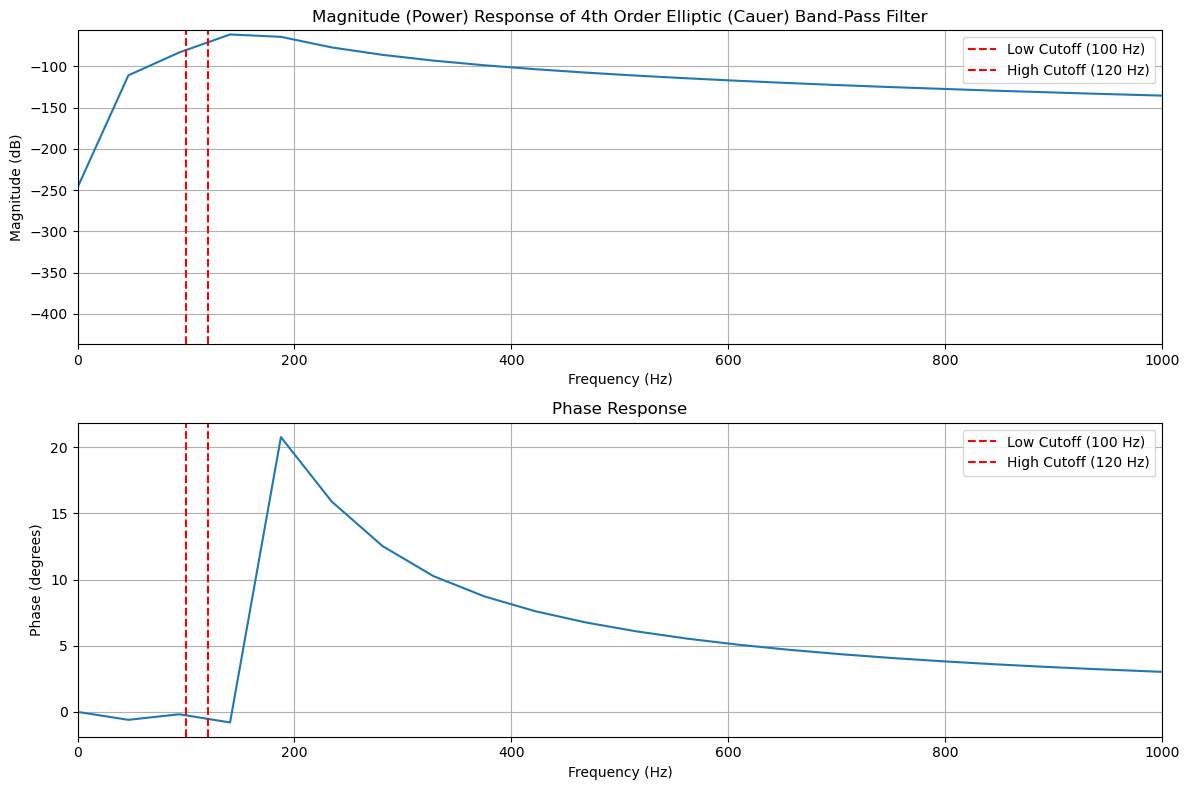


Filter plots generated successfully.
The magnitude plot shows the gain of the filter at different frequencies (in dB).
The phase plot shows the phase shift introduced by the filter at different frequencies (in degrees).


In [31]:


import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Filter Definition ---
# Example: Design a 4th order Elliptic (Cauer) bandpass filter
order = 4
sampling_rate_hz = sampleRate # Specify your actual sampling rate in Hz
low_cutoff_hz = 100     # Lower cutoff frequency in Hz
high_cutoff_hz = 120    # Upper cutoff frequency in Hz

# Elliptic filter specific parameters:
rp = 0.5   # Maximum ripple in the passband (dB)
rs = 40    # Minimum attenuation in the stopband (dB)

# Normalize cutoff frequencies to Nyquist frequency (sampling_rate_hz / 2)
nyquist_freq = 0.5 * sampling_rate_hz
normalized_low_cutoff = low_cutoff_hz / nyquist_freq
normalized_high_cutoff = high_cutoff_hz / nyquist_freq

# Ensure normalized cutoffs are within valid range [0, 1]
if not (0 < normalized_low_cutoff < 1) or not (0 < normalized_high_cutoff < 1):
    print("Warning: Normalized cutoff frequencies are out of expected range (0, 1).")
    print(f"Normalized Low Cutoff: {normalized_low_cutoff:.2f}, Normalized High Cutoff: {normalized_high_cutoff:.2f}")

# Get the filter coefficients (b: numerator, a: denominator) for Elliptic filter
# For bandpass, Wn expects a 2-element sequence [low, high]
#b, a = signal.ellip(order, rp, rs, [normalized_low_cutoff, normalized_high_cutoff], btype='bandpass', analog=False)
b, a = signal.butter(order,  [normalized_low_cutoff, normalized_high_cutoff], btype='bandpass', analog=False)

print(f"Filter Coefficients (b - numerator): {b}")
print(f"Filter Coefficients (a - denominator): {a}")
print(f"Designed a {order}th order Elliptic (Cauer) bandpass filter with cutoff frequencies {low_cutoff_hz} Hz and {high_cutoff_hz} Hz.")
print(f"Passband Ripple (rp): {rp} dB, Stopband Attenuation (rs): {rs} dB.")

# --- Frequency Response Calculation ---
# freqz computes the frequency response of a digital filter.
# w: array of angular frequencies where the response was computed (rad/sample).
# h: frequency response, complex numbers.
# We specify the sampling rate to get frequencies directly in Hz in the output `w`
w, h = signal.freqz(b, a, fs=sampling_rate_hz) # fs parameter returns w in Hz

maxfreq=1000
# frequencies is already in Hz because we passed fs to freqz
frequencies = w

# Calculate magnitude (power) in dB
magnitude_db = 20 * np.log10(abs(h))

# Calculate phase in degrees
phase_degrees = np.unwrap(np.angle(h)) * 180 / np.pi

# --- Plotting ---
plt.figure(figsize=(12, 8))

# Plot 1: Magnitude (Power) Response
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
plt.plot(frequencies, magnitude_db)
plt.title(f'Magnitude (Power) Response of {order}th Order Elliptic (Cauer) Band-Pass Filter')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.axvline(low_cutoff_hz, color='red', linestyle='--', label=f'Low Cutoff ({low_cutoff_hz:.0f} Hz)')
plt.axvline(high_cutoff_hz, color='red', linestyle='--', label=f'High Cutoff ({high_cutoff_hz:.0f} Hz)')
plt.legend()
plt.ylim(min(magnitude_db) - 5, max(magnitude_db) + 5) # Adjust y-limits for better view
plt.xlim(0, maxfreq) # Show frequencies up to sampling rate, or slightly beyond Nyquist

# Plot 2: Phase Response
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
plt.plot(frequencies, phase_degrees)
plt.title('Phase Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (degrees)')
plt.grid(True)
plt.axvline(low_cutoff_hz, color='red', linestyle='--', label=f'Low Cutoff ({low_cutoff_hz:.0f} Hz)')
plt.axvline(high_cutoff_hz, color='red', linestyle='--', label=f'High Cutoff ({high_cutoff_hz:.0f} Hz)')
plt.legend()
plt.xlim(0, maxfreq) # Show frequencies up to sampling rate, or slightly beyond Nyquist

plt.tight_layout() # Adjusts plot parameters for a tight layout
plt.show()

print("\nFilter plots generated successfully.")
print("The magnitude plot shows the gain of the filter at different frequencies (in dB).")
print("The phase plot shows the phase shift introduced by the filter at different frequencies (in degrees).")



Processing MIDI file: /home/gerald/workspace/src/GuitarMidi-LV2/assets/trainingdata/chromatic run/session_NNTranscription-1-t1.mid
Number of tracks: 1
note_on channel=0 note=40 velocity=90 time=0.2682291666666667
note_off channel=0 note=40 velocity=0 time=0.5458333333333333
note_on channel=0 note=41 velocity=97 time=0.034895833333333334
note_off channel=0 note=41 velocity=0 time=0.41770833333333335
note_on channel=0 note=42 velocity=94 time=0.04635416666666667
note_off channel=0 note=42 velocity=0 time=0.4296875
note_on channel=0 note=43 velocity=99 time=0.04635416666666667
note_off channel=0 note=43 velocity=0 time=0.44114583333333335
note_on channel=0 note=44 velocity=98 time=0.034895833333333334
note_off channel=0 note=44 velocity=0 time=0.47604166666666664
note_on channel=0 note=45 velocity=91 time=0.0234375
note_off channel=0 note=45 velocity=0 time=0.47604166666666664
note_on channel=0 note=46 velocity=93 time=0.04635416666666667
note_off channel=0 note=46 velocity=0 time=0.45260

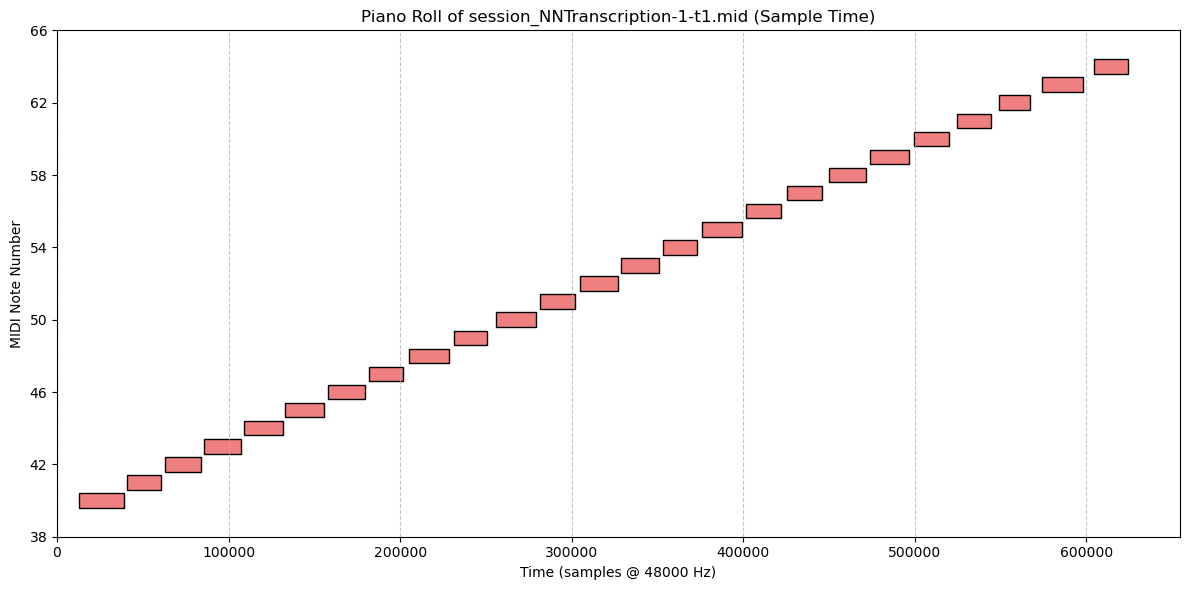

In [32]:
import mido
import matplotlib.pyplot as plt
import numpy as np

def load_midi_to_event_samples(midi_file_path,samplerate):
    """
    Loads MIDI data from a file, extracts note-on/off events,
    and plots them on a piano roll-like graph, converting all
    timestamps to samples based on the provided samplerate.
    Corrected time tracking for accurate absolute positions.

    Args:
        midi_file_path (str): The path to the MIDI file.
        samplerate (int): The audio sample rate (e.g., 44100, 48000)
                          to convert seconds to samples.
    """
    if samplerate <= 0:
        print("Error: Samplerate must be a positive integer.")
        return

    try:
        mid = mido.MidiFile(midi_file_path)
    except FileNotFoundError:
        print(f"Error: MIDI file not found at '{midi_file_path}'")
        return
    except Exception as e:
        print(f"Error loading MIDI file: {e}")
        return

    notes = []
    active_notes = {}
    
    # Absolute time in seconds, calculated from mido's stream iterator
    current_time_in_seconds = 0.0

    print(f"Processing MIDI file: {midi_file_path}")
    print(f"Number of tracks: {len(mid.tracks)}")

    # Iterate through the MIDI file as a whole stream, ordered by absolute time
    # This correctly accounts for inter-track timing and tempo changes.
    for msg in mid.play(): # mid.play() yields messages with msg.time in seconds
        
        # msg.time from mid.play() is the delta from the *previous* event in the *merged* stream
        print(msg)
        current_time_in_seconds += msg.time 

        if msg.type == 'note_on':
            # Store the note and its start time (in seconds)
            if msg.velocity > 0: 
                active_notes[msg.note] = current_time_in_seconds
            else: # Treat note_on with velocity 0 as note_off
                if msg.note in active_notes:
                    start_sec = active_notes.pop(msg.note)
                    duration_sec = current_time_in_seconds - start_sec
                    notes.append((msg.note, start_sec, duration_sec))

        elif msg.type == 'note_off':
            # Calculate duration when note_off occurs
            if msg.note in active_notes:
                start_sec = active_notes.pop(msg.note)
                duration_sec = current_time_in_seconds - start_sec
                notes.append((msg.note, start_sec, duration_sec))
        
        # Important: Filter out non-note messages that still advance time
        # The 'play()' iterator handles this, but if you were doing manual
        # tick processing, you'd only consider events that affect notes.
        # However, for correct *time*, all messages are important.

    # Handle any notes that were "on" when the file ended (missing note_off)
    # Assign them a duration until the end of the last recorded event
    for note, start_sec in list(active_notes.items()): # Use list() to iterate a copy
        duration_sec = current_time_in_seconds - start_sec
        notes.append((note, start_sec, duration_sec))



    
    return notes

def load_and_plot_midi_in_samples_corrected(midi_file_path, samplerate):
    notes=load_midi_to_event_samples(midi_file_path,samplerate)

    if not notes:
        print("No playable note events found in the MIDI file.")
        return

    # Convert all times from seconds to samples using the provided samplerate
    note_numbers = [n[0] for n in notes]
    start_times_samples = [int(n[1]*samplerate)  for n in notes] 
    durations_samples = [int(n[2]*samplerate) for n in notes]
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))

    for i in range(len(notes)):
        ax.barh(
            y=note_numbers[i],             
            width=durations_samples[i],            
            left=start_times_samples[i],           
            height=0.8,                    
            align='center',
            color='lightcoral', 
            edgecolor='black'
        )

    ax.set_xlabel(f"Time (samples @ {samplerate} Hz)")
    ax.set_ylabel("MIDI Note Number")
    ax.set_title(f"Piano Roll of {midi_file_path.split('/')[-1]} (Sample Time)")

    def midi_to_note_name(midi_note):
        NOTES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
        octave = (midi_note // 12) - 1 
        note_name = NOTES[midi_note % 12]
        return f"{note_name}{octave}"

    # Use the actual min/max of plotted notes for ylim, but ensure it's at least a small range
    if note_numbers:
        min_note = min(note_numbers) - 2
        max_note = max(note_numbers) + 2
    else: # Default for empty notes list
        min_note = 40
        max_note = 80

    ax.set_ylim(min_note, max_note)
    ax.set_xlim(0)
    note_range = max_note - min_note
    if note_range <= 12: 
        y_tick_interval = 1
    elif note_range <= 24: 
        y_tick_interval = 2
    else: 
        y_tick_interval = 4

    y_ticks = np.arange(int(min_note), int(max_note) + 1, y_tick_interval)
    # y_labels = [midi_to_note_name(int(note)) for note in y_ticks]
    ax.set_yticks(y_ticks)
    # ax.set_yticklabels(y_labels)

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
load_and_plot_midi_in_samples_corrected(midi_file,sampleRate)

Processing MIDI file: /home/gerald/workspace/src/GuitarMidi-LV2/assets/trainingdata/chromatic run/session_NNTranscription-1-t1.mid
Number of tracks: 1
note_on channel=0 note=40 velocity=90 time=0.2682291666666667
note_off channel=0 note=40 velocity=0 time=0.5458333333333333
note_on channel=0 note=41 velocity=97 time=0.034895833333333334
note_off channel=0 note=41 velocity=0 time=0.41770833333333335
note_on channel=0 note=42 velocity=94 time=0.04635416666666667
note_off channel=0 note=42 velocity=0 time=0.4296875
note_on channel=0 note=43 velocity=99 time=0.04635416666666667
note_off channel=0 note=43 velocity=0 time=0.44114583333333335
note_on channel=0 note=44 velocity=98 time=0.034895833333333334
note_off channel=0 note=44 velocity=0 time=0.47604166666666664
note_on channel=0 note=45 velocity=91 time=0.0234375
note_off channel=0 note=45 velocity=0 time=0.47604166666666664
note_on channel=0 note=46 velocity=93 time=0.04635416666666667
note_off channel=0 note=46 velocity=0 time=0.45260

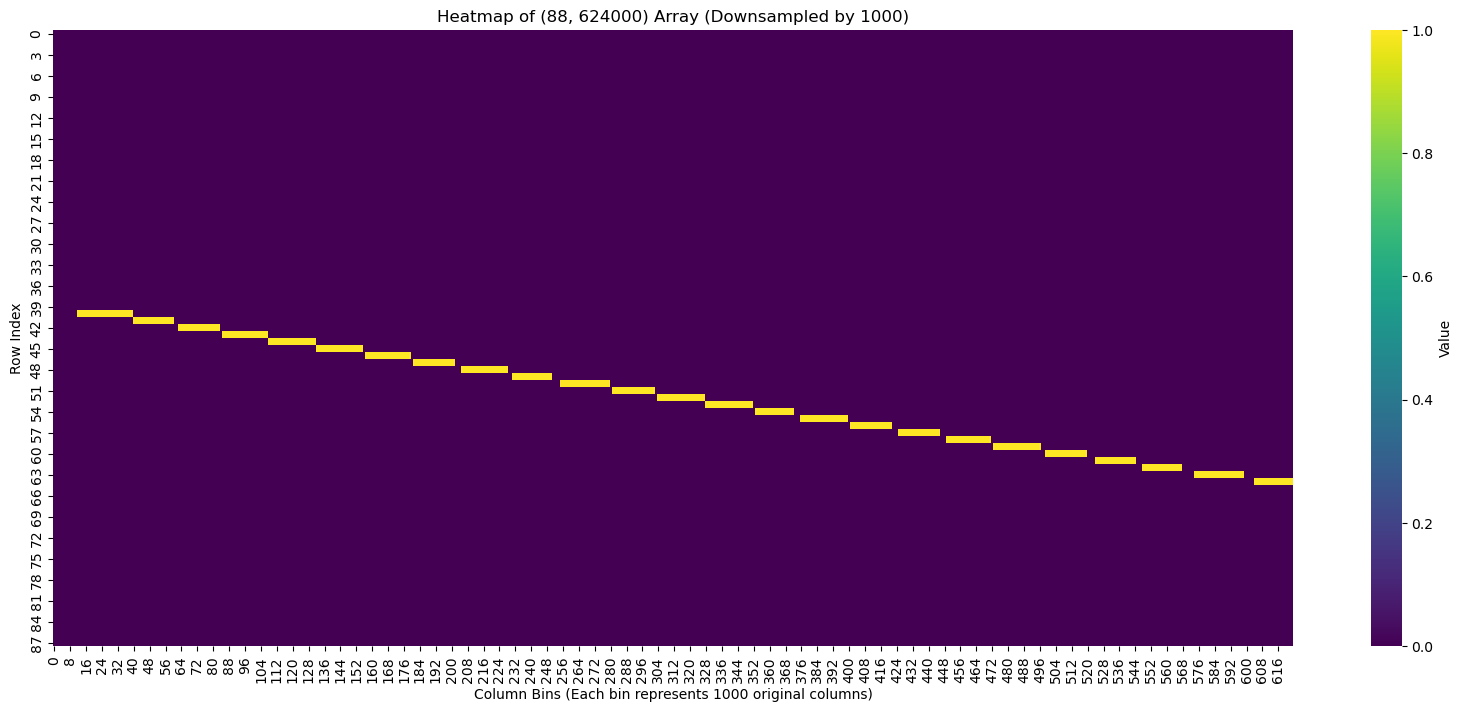

Heatmap displayed.
Downsampling data by a factor of 1000...
(312, 624000)
Downsampled array shape: (312, 624)
Creating heatmap...


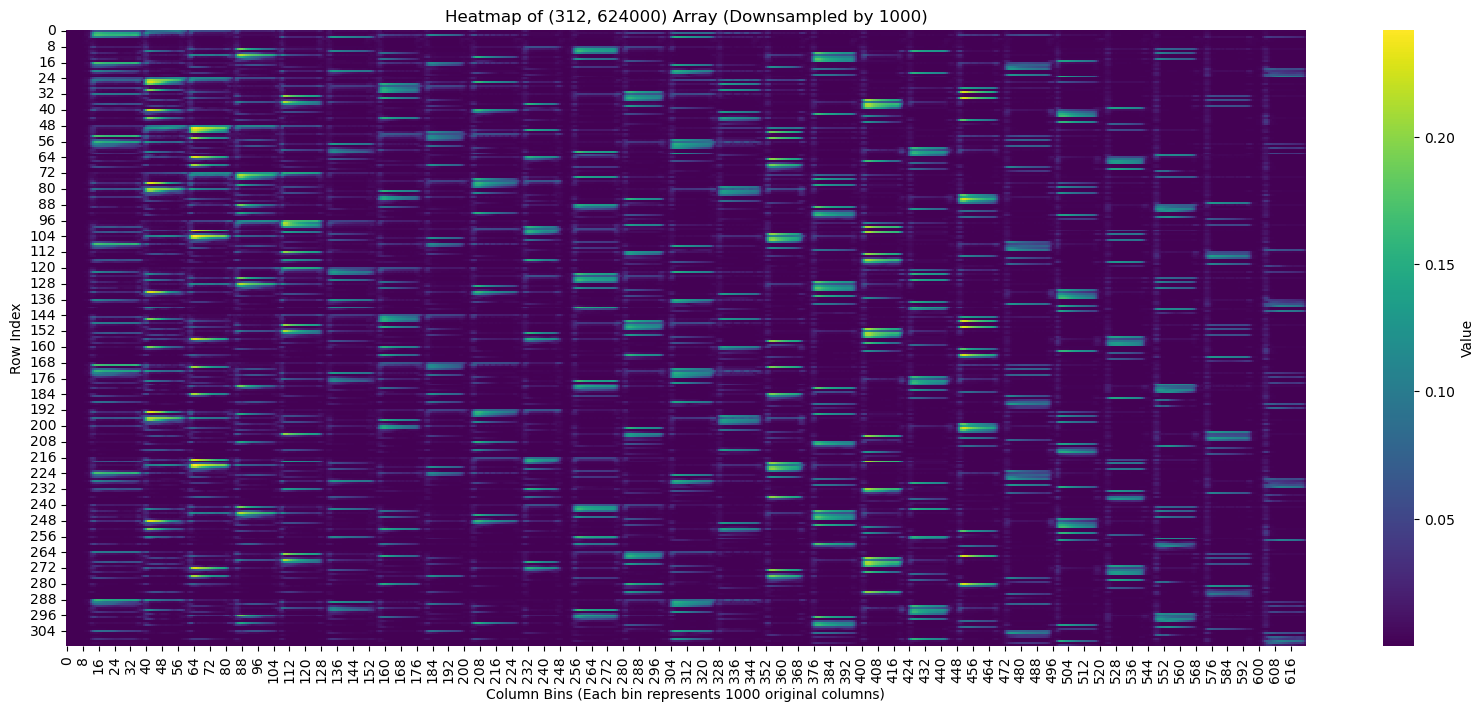

Heatmap displayed.


In [41]:
def generate_midi_classes(midi_file,samplerate,audiolength):
    num_midi_classes=88
    class_matrix=np.zeros((num_midi_classes,audiolength))
    notes=load_midi_to_event_samples(midi_file,samplerate)
    
    for n in notes:
        start_sample=int(n[1]*samplerate)
        duration_samples=int(n[2]*samplerate)
        class_matrix[n[0],start_sample:(start_sample+duration_samples)]=1
    return class_matrix
 
midi_classes=generate_midi_classes(midi_file,sampleRate,len(audiocut))   
plot_heatmap(midi_classes)
plot_heatmap(filterbank_out)

## Data preperation

In [ ]:
frame_size=256

def reshape_to_nn_input(indata):
    num_cols=indata.shape[1]
    num_rows=indata.shape[0]
    downsample_factor = frame_size
    # --- Downsampling the data ---
    print(f"reshape data by a factor of {downsample_factor}...")
    # Calculate the new number of columns after downsampling
    new_num_cols = num_cols // downsample_factor

    # Ensure the original number of columns is a multiple of the downsample_factor
    # If not, you might lose some data at the end or need a more complex aggregation.
    # For simplicity, we'll slice to a multiple of downsample_factor
    effective_cols = new_num_cols * downsample_factor
    data_sliced = indata[:, :effective_cols]
    print(data_sliced.shape)
    # Reshape the data for averaging:
    # -1: infer dimension
    # downsample_factor: group columns into blocks
    # num_rows: keep rows as isp
    # This reshapes (19, M*N) to (19, M, N)
    reshaped_data = data_sliced.reshape(num_rows, new_num_cols, downsample_factor)
    reshaped_data=np.swapaxes(reshaped_data,0,1)
    
    print('Reshaped the input data to  ')
    print(reshaped_data.shape)
    
def reshape_to_nn_output(outdata):
    num_cols=outdata.shape[1]
    num_rows=outdata.shape[0]
    downsample_factor = frame_size
    # --- Downsampling the data ---
    print(f"reshape data by a factor of {downsample_factor}...")
    # Calculate the new number of columns after downsampling
    new_num_cols = num_cols // downsample_factor

    # Ensure the original number of columns is a multiple of the downsample_factor
    # If not, you might lose some data at the end or need a more complex aggregation.
    # For simplicity, we'll slice to a multiple of downsample_factor
    effective_cols = new_num_cols * downsample_factor
    data_sliced = outdata[:, :effective_cols]
    print(data_sliced.shape)
    # Reshape the data for averaging:
    # -1: infer dimension
    # downsample_factor: group columns into blocks
    # num_rows: keep rows as isp
    # This reshapes (19, M*N) to (19, M, N)
    reshaped_data = data_sliced.reshape(num_rows, new_num_cols, downsample_factor)
    reshaped_data=np.max(reshaped_data,axis=2)
    reshaped_data=np.swapaxes(reshaped_data,0,1)
    
    print('Reshaped the output data to  ')
    print(reshaped_data.shape)

reshape_to_nn_input(filterbank_out)

reshape_to_nn_output(midi_classes)





reshape data by a factor of 256...
(312, 623872)
Reshaped the input data to  
(2437, 312, 256)
reshape data by a factor of 256...
(88, 623872)
Reshaped the output data to  
(2437, 88)
